In [ ]:
#phase 11 feature 11.2 
import numpy as np

# Data Manipulation
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Splitting Dataset
from sklearn.model_selection import train_test_split

# Classification Algorithms
from sklearn.linear_model import LogisticRegression


In [58]:
df = pd.read_csv("../data/Global_Cybersecurity_Threats_2015-2024.csv")

In [59]:
df.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


In [60]:
df.tail()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
2995,UK,2021,Ransomware,Government,51.42,190694,Unknown,Social Engineering,Firewall,52
2996,Brazil,2023,SQL Injection,Telecommunications,30.28,892843,Hacker Group,Zero-day,VPN,26
2997,Brazil,2017,SQL Injection,IT,32.97,734737,Nation-state,Weak Passwords,AI-based Detection,30
2998,UK,2022,SQL Injection,IT,32.17,379954,Insider,Unpatched Software,Firewall,9
2999,Germany,2021,SQL Injection,Retail,48.20,480984,Unknown,Zero-day,VPN,64


In [61]:
df.shape

(3000, 10)

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   str    
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   str    
 3   Target Industry                      3000 non-null   str    
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   int64  
 6   Attack Source                        3000 non-null   str    
 7   Security Vulnerability Type          3000 non-null   str    
 8   Defense Mechanism Used               3000 non-null   str    
 9   Incident Resolution Time (in Hours)  3000 non-null   int64  
dtypes: float64(1), int64(3), str(6)
memory usage: 234.5 KB


In [63]:
df.describe()

,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2019.570333,50.492970,504684.136333,36.476000
std,2.857932,28.791415,289944.084972,20.570768
min,2015.000000,0.500000,424.000000,1.000000
25%,2017.000000,25.757500,255805.250000,19.000000
50%,2020.000000,50.795000,504513.000000,37.000000
75%,2022.000000,75.630000,758088.500000,55.000000
max,2024.000000,99.990000,999635.000000,72.000000


In [64]:
df.columns

Index(['Country', 'Year', 'Attack Type', 'Target Industry',
       'Financial Loss (in Million $)', 'Number of Affected Users',
       'Attack Source', 'Security Vulnerability Type',
       'Defense Mechanism Used', 'Incident Resolution Time (in Hours)'],
      dtype='str')

In [65]:
df.isnull().sum()

Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
dtype: int64

In [66]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['High-']

setting the targets for the logistic classification 

In [68]:
df.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours),High_Loss
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63,1
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71,1
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20,0
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7,0
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68,1


checking class distrubution 


In [69]:
df["High_Loss"].value_counts()

High_Loss
1    1500
0    1500
Name: count, dtype: int64

In [70]:
df["High_Loss"].value_counts(normalize=True)

High_Loss
1    0.5
0    0.5
Name: proportion, dtype: float64

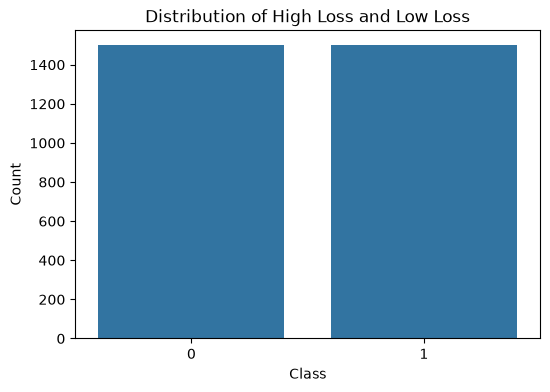

In [71]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="High_Loss",
    data=df
)

plt.title("Distribution of High Loss and Low Loss")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [72]:
# Independent Variables (Features)
X = df.drop(
    columns=[
        "Financial Loss (in Million $)",
        "High_Loss"
    ]
)

# Dependent Variable (Target)
Y = df["High_Loss"]

In [73]:
X.head()

,Country,Year,Attack Type,Target Industry,Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,810682,Insider,Social Engineering,VPN,68


In [74]:
Y.head()

0    1
1    1
2    0
3    0
4    1
Name: High_Loss, dtype: int64

In [75]:
print("Shape of X :", X.shape)
print("Shape of Y :", Y.shape)

Shape of X : (3000, 9)
Shape of Y : (3000,)


encoding 

In [76]:
X.select_dtypes(include="object").columns

/tmp/ipykernel_13471/2213039483.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include="object").columns


Index(['Country', 'Attack Type', 'Target Industry', 'Attack Source',
       'Security Vulnerability Type', 'Defense Mechanism Used'],
      dtype='str')

In [77]:
label_encoder = LabelEncoder()
for column in X.select_dtypes(include="object").columns:
    X[column] = label_encoder.fit_transform(X[column])

/tmp/ipykernel_13471/1487910370.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in X.select_dtypes(include="object").columns:


In [78]:
X.head()

,Country,Year,Attack Type,Target Industry,Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,2,2019,3,1,773169,0,1,4,63
1,2,2019,4,5,295961,0,1,3,71
2,5,2017,2,4,605895,0,2,4,20
3,8,2024,4,6,659320,2,0,0,7
4,4,2018,2,4,810682,1,0,4,68


In [79]:
now traintest split 

SyntaxError: invalid syntax (1191673871.py, line 1)

In [80]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [81]:
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

print("Y_train :", Y_train.shape)
print("Y_test :", Y_test.shape)

X_train : (2400, 9)
X_test : (600, 9)
Y_train : (2400,)
Y_test : (600,)


In [82]:
print(Y_train.value_counts())

High_Loss
1    1200
0    1200
Name: count, dtype: int64


In [84]:
print(Y_test.value_counts())

High_Loss
1    300
0    300
Name: count, dtype: int64


feature scaling 

In [86]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [87]:
print(X_train[:5])

[[-0.89098988 -0.90052346 -0.84010851  0.52185705  0.02155906  0.41334118
   1.31010896  1.40527873 -0.89398305]
 [-0.89098988  0.49699112  1.46550662 -0.48859629 -0.96293676 -0.49178549
   1.31010896  0.69866466  1.00538849]
 [-0.5430036   0.84636977 -0.84010851 -0.99382296  0.87885003 -0.49178549
  -1.35979891 -0.00794941 -1.08879039]
 [-1.23897617  1.54512707 -1.4165123   0.01663038 -0.06911035 -1.39691217
  -0.46982962  1.40527873 -1.33229956]
 [ 1.54491411 -0.20176617 -1.4165123   1.53231039 -0.81692917  1.31846786
  -0.46982962 -0.71456348 -0.30956103]]


trainig the model logistic classification 

In [88]:
# Create Logistic Regression model
model = LogisticRegression()

# Train the model
model.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [90]:
# Predict classes
Y_pred = model.predict(X_test)

In [93]:
model.predict(X_train)

array([0, 0, 1, ..., 0, 1, 1], shape=(2400,))

In [94]:
model.predict_proba(X_test)

array([[0.56130541, 0.43869459],
       [0.50206574, 0.49793426],
       [0.46151006, 0.53848994],
       ...,
       [0.5008907 , 0.4991093 ],
       [0.46517178, 0.53482822],
       [0.51503418, 0.48496582]], shape=(600, 2))

In [95]:
model.coef_

array([[ 0.01458853,  0.05620114, -0.03843493, -0.02944915,  0.00401113,
        -0.00078559, -0.00163075, -0.04215831, -0.02764719]])

display feature importance 


In [96]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef_df

,Feature,Coefficient
0,Country,0.014589
1,Year,0.056201
2,Attack Type,-0.038435
3,Target Industry,-0.029449
4,Number of Affected Users,0.004011
5,Attack Source,-0.000786
6,Security Vulnerability Type,-0.001631
7,Defense Mechanism Used,-0.042158
8,Incident Resolution Time (in Hours),-0.027647


In [97]:
coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
1,Year,0.056201
0,Country,0.014589
4,Number of Affected Users,0.004011
5,Attack Source,-0.000786
6,Security Vulnerability Type,-0.001631
8,Incident Resolution Time (in Hours),-0.027647
3,Target Industry,-0.029449
2,Attack Type,-0.038435
7,Defense Mechanism Used,-0.042158


In [98]:
model.intercept_

array([-1.33527024e-06])

In [99]:
model.classes_

array([0, 1])

In [100]:
model.n_features_in_

9

In [103]:
model.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': 0.0,
 'max_iter': 100,
 'n_jobs': None,
 'penalty': 'deprecated',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}